<div style="text-align:left;">
  <p><em>Prepared by Latreche Sara</em></p>
</div>

<center><font size=6><b>End-to-End Regression Pipeline & Hyperparameter Tuning</b></font></center>

<div style="text-align:center;">
    <img src="./assets/california.PNG" width="450"/>
</div>

***

**Author**: Latreche Sara  
**Date**: June 2026  

### Table of Contents

- [1 | Pipeline Architecture & Objectives](#1-pipeline-architecture)
- [2 | Environment Setup & Dataset Loading](#2-setup)
- [3 | Feature Engineering & Robust Preprocessing Pipeline](#3-preprocessing)
- [4 | Training](#4-benchmark)
- [5 | Hyperparameter Tuning via RandomizedSearchCV](#5-tuning)
- [6 | Model Diagnosis & Residual Analysis](#6-diagnosis)
- [7 | Model Interpretability (SHAP Global & Local Explanations)](#7-interpretability)
- [8 | Production Deployment & Model Serialization](#8-serialization)




## <b><a id="2-setup">2 <span style='color:#770A7A'>|</span> Environment Setup & Dataset Loading</a></b>
*Environment initialization, importing core libraries (Scikit-Learn, XGBoost, LightGBM, CatBoost, SHAP), and loading the clean file `cleaned_dataset.csv`.*

In [ ]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

In [3]:
df= pd.read_csv("data.csv")

## <b><a id="3-preprocessing">3 <span style='color:#770A7A'>|</span> Feature Engineering & Robust Preprocessing Pipeline</a></b>
*Execution of the standard `train_test_split` (with verified distributional stability over 74k rows) and configuration of the `ColumnTransformer`. We employ a `RobustScaler` (leveraging the median and Interquartile Range - IQR) to neutralize the long, skewed tails observed in our boxplots without discarding valid high-end property information, paired with a `OneHotEncoder` for categorical dimensions.*


In [5]:
# ==========================================
# 0. LOAD DATA & RUN THE TRAIN-TEST SPLIT
# ==========================================
# df = pd.read_csv("housing.csv") # Make sure your data is loaded

X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

# Split the data first to protect your test set from any data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## <b><a id="3-preprocessing">3 <span style='color:#770A7A'>|</span> Feature Engineering & Robust Preprocessing Pipeline</a></b>
*Execution of the standard `train_test_split` (with verified distributional stability over 74k rows) and configuration of the `ColumnTransformer`. We employ a `RobustScaler` (leveraging the median and Interquartile Range - IQR) to neutralize the long, skewed tails observed in our boxplots without discarding valid high-end property information, paired with a `OneHotEncoder` for categorical dimensions.*


In [6]:
# ==========================================
# 1. SETUP RAW PIPELINE MATRIX (Using X_train now)
# ==========================================
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

In [7]:
# ==========================================
# 1. SETUP RAW PIPELINE MATRIX
# ==========================================
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", RobustScaler()),
                ]
            ),
            num_cols,
        ),
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "encoder",
                        OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                    ),
                ]
            ),
            cat_cols,
        ),
    ]
)

In [8]:
# Wrap preprocessor and the base model into one master structural pipeline
full_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("rf_reg", RandomForestRegressor(random_state=42, n_jobs=-1)),
    ]
)

## <b><a id="4-benchmark">4 <span style='color:#770A7A'>|</span> Running random forest</a></b>


In [9]:
# ==========================================
# 2. RANDOMIZED SEARCH CONFIGURATION
# ==========================================
# Broad parameters to search over efficiently
param_distributions = {
    "rf_reg__n_estimators": [50, 100, 200, 300],
    "rf_reg__max_features": [4, 6, 8, 10],
    "rf_reg__max_depth": [15, 20, 25, None],
    "rf_reg__min_samples_split": [2, 5, 10],
}

## <b><a id="5-tuning">5 <span style='color:#770A7A'>|</span> Hyperparameter Tuning via RandomizedSearchCV</a></b>
*Fine-tuning the champion architecture (XGBoost / LightGBM) by exploring the hyperparameter space via cross-validated random search (`RandomizedSearchCV`). Optimizing tree depth (`max_depth`), learning rate (`learning_rate`), and row/column subsampling (`subsample`) to push past the $70\%$ variance explained ceiling.*


In [10]:
random_search = RandomizedSearchCV(
    estimator=full_pipeline,
    param_distributions=param_distributions,
    n_iter=10,  # Randomly samples 10 configurations to save time
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
)

print("Starting hyperparameter tuning optimization...")
random_search.fit(X_train, y_train)

Starting hyperparameter tuning optimization...


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'rf_reg__max_depth': [15, 20, ...], 'rf_reg__max_features': [4, 6, ...], 'rf_reg__min_samples_split': [2, 5, ...], 'rf_reg__n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV

In [11]:
# ==========================================
# 3. EXTRACTION & EVALUATION
# ==========================================
print(f"\nBest CV R2 Score: {random_search.best_score_:.4f}")
print(f"Best Hyperparameters found: {random_search.best_params_}")


Best CV R2 Score: 0.8201
Best Hyperparameters found: {'rf_reg__n_estimators': 50, 'rf_reg__min_samples_split': 5, 'rf_reg__max_features': 10, 'rf_reg__max_depth': 25}


In [12]:
# Pull the absolute best unified pipeline out
production_pipeline = random_search.best_estimator_

In [13]:
# Validate generalization on test split
final_test_r2 = production_pipeline.score(X_test, y_test)
print(f"Final Test Set R2 Score: {final_test_r2:.4f}")

Final Test Set R2 Score: 0.8181


## <b><a id="6-diagnosis">6 <span style='color:#770A7A'>|</span> Model Diagnosis & Residual Analysis</a></b>
*A deep dive into model error patterns. Generating diagnostic plots: residual distributions (to verify normality assumptions), predicted vs. actual outcome tracking, and visual checks for heteroscedasticity to pinpoint where the model struggles to fit.*



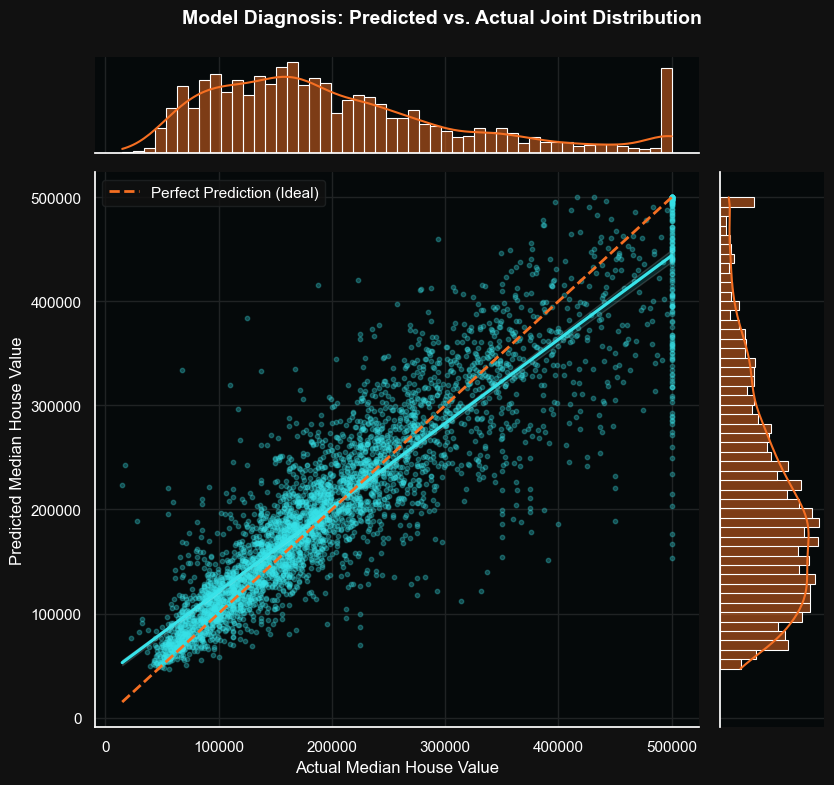

In [16]:
# ==========================================
# 5. DIAGNOSIS VISUALIZATION (JOINT PLOT)
# ==========================================
# Generate predictions on the test set for plotting
y_pred = production_pipeline.predict(X_test)

# Setup your signature dark theme styling
sns.set_theme(
    style="darkgrid",
    rc={
        "figure.facecolor": "#111111",
        "axes.facecolor": "#05090a",
        "grid.color": "#202324",
        "text.color": "white",
        "xtick.color": "white",
        "ytick.color": "white",
    },
)

# Create the Joint Plot with alpha inside scatter_kws to prevent crashing
g = sns.jointplot(
    x=y_test,
    y=y_pred,
    kind="reg",
    color="#38E3E9",
    height=8,
    marginal_kws=dict(bins=50, fill=True, color="#F56F22"),
    scatter_kws=dict(s=10, color="#38E3E9", alpha=0.3),
)

# Draw a Perfect Prediction line (y = x) as a structural target reference
ax = g.ax_joint
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="#F56F22",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction (Ideal)",
)

# Labeling and layout tuning
ax.set_xlabel("Actual Median House Value", color="white", fontsize=12)
ax.set_ylabel("Predicted Median House Value", color="white", fontsize=12)
ax.legend(loc="upper left", facecolor="#111111", edgecolor="#202324")

g.fig.subplots_adjust(top=0.92)
g.fig.suptitle(
    "Model Diagnosis: Predicted vs. Actual Joint Distribution",
    color="white",
    fontsize=14,
    fontweight="bold",
)

plt.show()

## <b><a id="7-interpretability">7 <span style='color:#770A7A'>|</span> Model Interpretability (SHAP Global & Local Explanations)</a></b>
*Opening the boosting model's "black box" using SHAP (Shapley Additive exPlanations) values. Visualizing global feature importances via Summary Plots to quantify the exact marginal contribution of elements like `room_type` or location, alongside local Force Plots to dissect individual listing price predictions.*


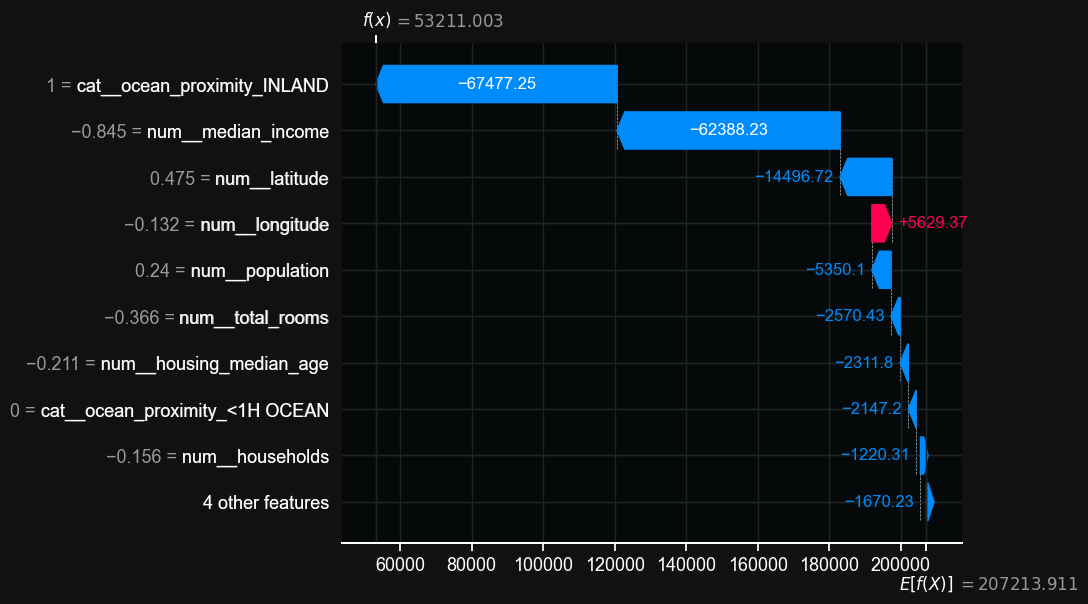

In [18]:
import shap

# 1. Get the preprocessor and model directly out of your saved pipeline
preprocessor = production_pipeline.named_steps["preprocessor"]
rf_model = production_pipeline.named_steps["rf_reg"]

# 2. Transform the data and automatically extract the clean feature names
# get_feature_names_out() reads your OneHotEncoder and RobustScaler steps automatically!
X_test_processed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

# 3. Pass the processed matrix and the standalone model to SHAP
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_test_processed)

# 4. Bind the automatically extracted names right to the SHAP object
shap_values.feature_names = list(feature_names)

# 5. Plot!
sample_index = 0
shap.plots.waterfall(shap_values[sample_index], max_display=10)

## <b><a id="8-serialization">8 <span style='color:#770A7A'>|</span> Production Deployment & Model Serialization</a></b>
*Saving and serializing the final end-to-end production pipeline (encapsulating both the robust preprocessor and the fine-tuned regressor) using `joblib` or `pickle`. A final verification step ensures the saved asset can be reloaded instantaneously for reliable inference on fresh incoming listings.*

In [14]:
# ==========================================
# 4. EXPORT PIPELINE FOR WEB APP
# ==========================================
# This saves encoder, robust scaler, and random forest weights together!
filename = "california_housing_production_pipeline.pkl"
joblib.dump(production_pipeline, filename)
print(f"\nSuccess! Final integrated pipeline saved as: '{filename}'")


Success! Final integrated pipeline saved as: 'california_housing_production_pipeline.pkl'
